# Condensation: A Demo Ideal_Gas Can't Produce

`Ideal_Gas`'s hard-sphere elastic collisions have no attraction -- particles
only ever interact by bouncing apart, so the gas always stays uniformly
spread out no matter how cold it gets. The Lennard-Jones attraction in
`vdw_gas.py` changes that: cool the gas down and particles should pull
each other into clusters instead.

**Protocol**: equilibrate a gas at a moderate temperature first (so
particles have genuinely explored the box, not just sitting on their
initial lattice), then either cool the thermostat target down (watch it
condense) or leave it at the same temperature (stays gas-like) --
starting both runs from the identical equilibrated state, so the only
difference is what happens after.

**Clustering metric**: mean number of neighbors within `1.5*sigma` per
particle (roughly the first coordination shell/attractive-well range) --
near zero for a dilute, uncorrelated gas, and growing as particles
aggregate into clusters.

In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import vdw_gas as vdw

os.makedirs('media', exist_ok=True)
device = torch.device('cpu')

def neighbor_count(rs, cutoff, frames):
    """Mean number of neighbors within `cutoff`, per particle, averaged over `frames`."""
    counts = []
    for i in frames:
        d = torch.cdist(rs[i].T, rs[i].T)
        counts.append(((d < cutoff) & (d > 0)).sum(dim=1).float().mean().item())
    return np.array(counts)

## Simulate: equilibrate, then branch into cooled vs. held-hot

In [2]:
epsilon, sigma = 1.0, 0.03
N = 5000
L = 1.0 * (N / 150) ** 0.5  # scale the box to keep density the same as the original N=150 demo
dt = 5e-5
thermostat_every = 20
cluster_cutoff = 1.5 * sigma          # clustering-metric radius (unrelated to the LJ force cutoff below)
lj_cutoff = 2.5 * sigma                # LJ force cutoff -- enables vdw.motion's neighbor-list mode

print(f'N={N}, L={L:.3f} (density matches the original N=150, L=1.0 demo)')

n_side = int(np.ceil(np.sqrt(N)))
spacing = 0.9 * L / n_side
xs, ys = torch.meshgrid(torch.arange(n_side) * spacing + 0.05 * L, torch.arange(n_side) * spacing + 0.05 * L, indexing='ij')
r0 = torch.stack([xs.flatten()[:N], ys.flatten()[:N]])

torch.manual_seed(1)
v0 = torch.randn((2, N)) * np.sqrt(1.0)

# Stage 1: equilibrate as a gas at T=1.0 so particles have genuinely
# explored the box before the cold/hot runs branch off from an identical
# state.
ts_equil = 3000
t0 = time.perf_counter()
rs_equil, vs_equil, _ = vdw.motion(r0.clone(), v0.clone(), ts_equil, dt, epsilon, sigma, L=L, cutoff=lj_cutoff,
                                    track_pressure=False, thermostat_T=1.0, thermostat_every=thermostat_every)
print(f'equilibration ({time.perf_counter()-t0:.1f}s): neighbor count = '
      f'{neighbor_count(rs_equil, cluster_cutoff, range(ts_equil-200, ts_equil, 20)).mean():.3f}')
r_mid, v_mid = rs_equil[-1].clone(), vs_equil[-1].clone()

# Stage 2: branch into a cooled run and a still-hot run from the same
# equilibrated state.
T_cold, T_hot = 0.03, 1.0
ts = 6000
t0 = time.perf_counter()
rs_cold, vs_cold, _ = vdw.motion(r_mid.clone(), v_mid.clone(), ts, dt, epsilon, sigma, L=L, cutoff=lj_cutoff,
                                  track_pressure=False, thermostat_T=T_cold, thermostat_every=thermostat_every)
print(f'cold run (T={T_cold}) done ({time.perf_counter()-t0:.1f}s)')
t0 = time.perf_counter()
rs_hot, vs_hot, _ = vdw.motion(r_mid.clone(), v_mid.clone(), ts, dt, epsilon, sigma, L=L, cutoff=lj_cutoff,
                                track_pressure=False, thermostat_T=T_hot, thermostat_every=thermostat_every)
print(f'hot run (T={T_hot}) done ({time.perf_counter()-t0:.1f}s)')

N=5000, L=5.774 (density matches the original N=150, L=1.0 demo)


equilibration (12.7s): neighbor count = 0.998


cold run (T=0.03) done (28.0s)


hot run (T=1.0) done (28.1s)


## Quantitative check: does cooling actually increase clustering?

final mean neighbor count: cold (T=0.03) = 2.371, hot (T=1.0) = 1.052
PASS: the cooled gas ends up with 2.3x the hot gas's neighbor count -- clustering that Ideal_Gas's attraction-free hard-sphere collisions cannot produce.


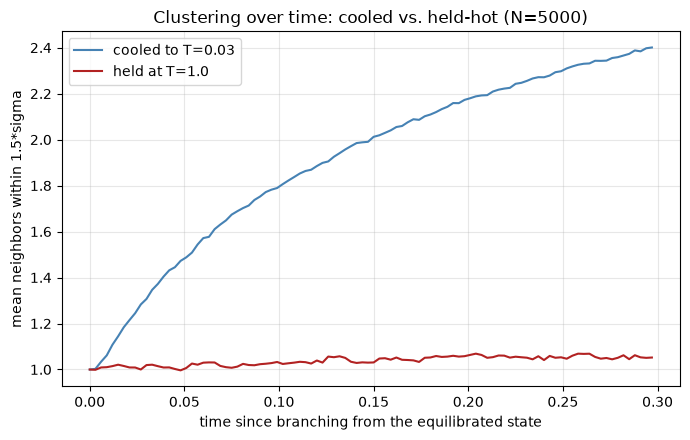

In [3]:
check_frames = range(0, ts, 60)
nc_cold = neighbor_count(rs_cold, cluster_cutoff, check_frames)
nc_hot = neighbor_count(rs_hot, cluster_cutoff, check_frames)
t_axis = np.array(list(check_frames)) * dt

final_cold = nc_cold[-10:].mean()
final_hot = nc_hot[-10:].mean()
print(f'final mean neighbor count: cold (T={T_cold}) = {final_cold:.3f}, hot (T={T_hot}) = {final_hot:.3f}')
assert final_cold > 2 * final_hot, 'cooled gas should show substantially more clustering than the hot gas'
print(f'PASS: the cooled gas ends up with {final_cold/final_hot:.1f}x the hot gas\'s neighbor count -- '
      f'clustering that Ideal_Gas\'s attraction-free hard-sphere collisions cannot produce.')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_axis, nc_cold, label=f'cooled to T={T_cold}', color='steelblue')
ax.plot(t_axis, nc_hot, label=f'held at T={T_hot}', color='firebrick')
ax.set_xlabel('time since branching from the equilibrated state')
ax.set_ylabel(f'mean neighbors within {cluster_cutoff/sigma:.1f}*sigma')
ax.set_title(f'Clustering over time: cooled vs. held-hot (N={N})')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/clustering_metric.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation: cooled (condensing) vs. held-hot (stays gas-like)

In [4]:
frame_stride = 30
frame_idxs = list(range(0, ts, frame_stride))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.7))
scat_cold = axes[0].scatter(rs_cold[0, 0], rs_cold[0, 1], s=2, color='steelblue')
axes[0].set_xlim(0, L); axes[0].set_ylim(0, L); axes[0].set_aspect('equal')
axes[0].set_title(f'cooled to T = {T_cold}')
scat_hot = axes[1].scatter(rs_hot[0, 0], rs_hot[0, 1], s=2, color='firebrick')
axes[1].set_xlim(0, L); axes[1].set_ylim(0, L); axes[1].set_aspect('equal')
axes[1].set_title(f'held at T = {T_hot}')
fig.suptitle(f'N = {N:,} particles')
time_text = fig.text(0.5, 0.02, '', ha='center', fontsize=11)

def animate(k):
    i = frame_idxs[k]
    scat_cold.set_offsets(rs_cold[i].T.numpy())
    scat_hot.set_offsets(rs_hot[i].T.numpy())
    time_text.set_text(f't = {i * dt:.3f}')
    return scat_cold, scat_hot, time_text

ani = animation.FuncAnimation(fig, animate, frames=len(frame_idxs), interval=40, blit=True)
ani.save('media/condensation.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/condensation.mp4')

saved media/condensation.mp4
